In [42]:
#Import Libraries
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import kruskal, mannwhitneyu, spearmanr, skew

# ML preprocessing
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [43]:
#Download Data
data = pd.read_excel("../data/ctech projects (CA).xlsx")

print("Shape:", data.shape)
data.head()


Shape: (46608, 30)


,Flex Project UUID,Confirmation Year,Handler Region,Product Group,Product Type,Product Type Code,Product Type Segment,Industry Name,Industry Code,Service Line Code,Service Line Name,Service Detail,Service Program,Service Catalog Category,Service Catalog Item Number,Service Catalog Segment,Service Catalog Sub Category,CCN,Ship to Customer Region,Has Test Task Flag,Ship to Account Number,Flex Standards,Standard Count,Avg Scoped Hours Engineer,Avg Scoped Hours Lab,Flex Project Count,Total Scoped Hours,Actual Eng Hours,Actual Lab Hours,Test Count
0,00006a1e-851e-416b-b3ef-6185b8d8c134,2025,Americas,NaN,"Networking Devices (Router, Bridge, Hub, Modem...",UL_SERVICE,NaN,High Tech,111,102,Safety Certification Services,UL and cUL Mark Bundle (Revision of existing c...,Alternate Construction,PRDC,30056282-CPQ,CRT,North America Market Services,AZOT,Americas,No,1459815,"UL 62368-1 AUDIO/VIDEO, INFORMATION AND COMMUN...",2,7.0,0.00,1,7.00,8.15,0.00,0
1,0000abd2-02b6-4fe2-9c15-f023218ff27c,2025,APAC,Display Devices,Display LED/LCD TV/Monitor (< 20 in.),UL_SERVICE,NaN,High Tech,111,797,Consumer EMC Testing,EMC Customer Directed Testing,Other EMC Services,EMCT,30055064-CPQ,TST,Global Market Services,AAAD,Asia,Yes,2983469,NaN,0,1.0,6.00,1,7.00,0.00,6.00,0
2,0002eafc-ac66-4797-8a1e-e6bfe890c118,2025,EMEA,NaN,"Networking Devices (Router, Bridge, Hub, Modem...",UL_SERVICE,NaN,High Tech,111,797,Consumer EMC Testing,EN 301 489-1; EN 301 489-17,EMC-RED,EMCT,30055075-CPQ,TST,Europe Market Services,NaN,EMEA,Yes,244675,NaN,0,19.0,63.75,1,82.75,12.00,88.25,0
3,0003ad27-5a88-4bf4-91aa-0f2477cf71aa,2025,APAC,Patient Monitor,Non-Invasive Blood Pressure (NIBP),UL_SERVICE,NaN,Health Sciences,701,789,Consumer Wireless Regulatory Testing,EN 300 328,Wireless Regulatory,WRTG,30055268-CPQ,TST,Europe Market Services,NaN,Asia,Yes,730212,NaN,0,24.0,8.00,1,32.00,3.00,6.50,0
4,0005bc78-184e-4633-9440-d9f8b2596feb,2025,APAC,Rechargeable,"Battery Pack (Lithium, Rechargeable)",UL_SERVICE,NaN,High Tech,111,102,Safety Certification Services,CB Test Report and Certificate (New Certificat...,New Construction,PRDC,30054080-CPQ,CRT,Global Market Services,AAAE,Asia,Yes,579813,"IEC 62133-2, Secondary cells and batteries con...",1,16.0,16.00,1,32.00,11.50,9.00,4


In [44]:
#List column Name in a python list
data.columns.tolist()

['Flex Project UUID',
 'Confirmation Year',
 'Handler Region',
 'Product Group',
 'Product Type',
 'Product Type Code',
 'Product Type Segment',
 'Industry Name',
 'Industry Code',
 'Service Line Code',
 'Service Line Name',
 'Service Detail',
 'Service Program',
 'Service Catalog Category',
 'Service Catalog Item Number',
 'Service Catalog Segment',
 'Service Catalog Sub Category',
 'CCN',
 'Ship to Customer Region',
 'Has Test Task Flag',
 'Ship to Account Number',
 'Flex Standards',
 'Standard Count',
 'Avg Scoped Hours Engineer',
 'Avg Scoped Hours Lab',
 'Flex Project Count',
 'Total Scoped Hours',
 'Actual Eng Hours',
 'Actual Lab Hours',
 'Test Count']

In [45]:
#Check how many missing values each column has and the %
missing_summary = pd.DataFrame({
    "Missing_Count": data.isna().sum(),
    "Missing_Percent": data.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percent",
    ascending=False
)

missing_summary[missing_summary["Missing_Count"] > 0]


,Missing_Count,Missing_Percent
Product Type Segment,45377,97.358823
Flex Standards,33323,71.496310
Avg Scoped Hours Lab,19239,41.278321
Product Group,16853,36.159028
CCN,12671,27.186320
Avg Scoped Hours Engineer,3328,7.140405
Actual Lab Hours,684,1.467559
Actual Eng Hours,684,1.467559
Service Program,576,1.235839
Service Detail,544,1.167182


In [46]:
#Check for duplicates
print("Total Rows:", len(data))
print("Duplicate Rows:", data.duplicated().sum())

Total Rows: 46608
Duplicate Rows: 0


In [47]:
#Check Data types

data.dtypes

Flex Project UUID                   str
Confirmation Year                   str
Handler Region                      str
Product Group                       str
Product Type                        str
Product Type Code                   str
Product Type Segment            float64
Industry Name                       str
Industry Code                       str
Service Line Code                   str
Service Line Name                   str
Service Detail                      str
Service Program                     str
Service Catalog Category            str
Service Catalog Item Number         str
Service Catalog Segment             str
Service Catalog Sub Category        str
CCN                                 str
Ship to Customer Region             str
Has Test Task Flag                  str
Ship to Account Number            int64
Flex Standards                      str
Standard Count                    int64
Avg Scoped Hours Engineer       float64
Avg Scoped Hours Lab            float64


In [48]:
#Summary Stats
data["Actual Eng Hours"].describe()

count    45924.000000
mean        12.594231
std         19.923312
min          0.000000
25%          3.250000
50%          7.500000
75%         15.042500
max        971.650000
Name: Actual Eng Hours, dtype: float64

12.537138657926373


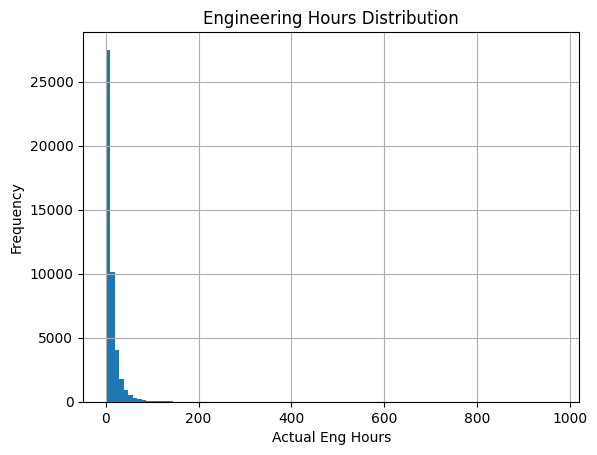

In [49]:
print(skew(data["Actual Eng Hours"].dropna()))

data["Actual Eng Hours"].hist(bins=100)

plt.title("Engineering Hours Distribution")
plt.xlabel("Actual Eng Hours")
plt.ylabel("Frequency")

plt.show()


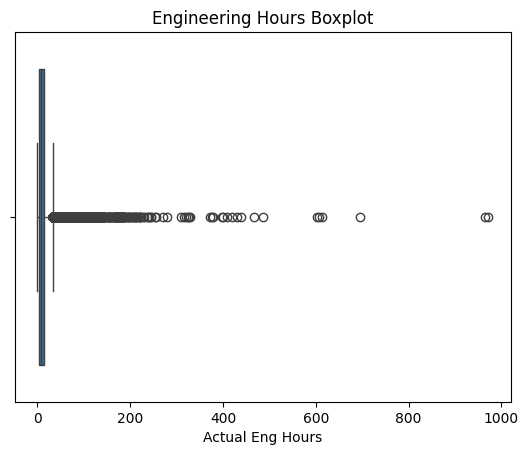

In [50]:
#Boxplot for Outliers

sns.boxplot(x=data["Actual Eng Hours"])

plt.title("Engineering Hours Boxplot")
plt.show()


0.15548819843091594


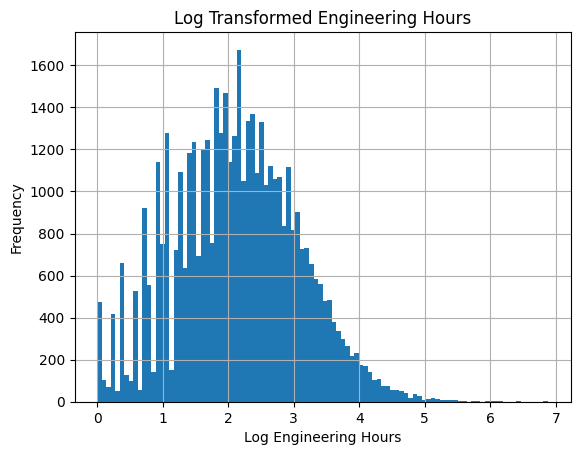

In [51]:
#test log transformation 
data["Log_Eng_Hours"] = np.log1p(data["Actual Eng Hours"])

print(skew(data["Log_Eng_Hours"].dropna()))


#then visualize it

data["Log_Eng_Hours"].hist(bins=100)

plt.title("Log Transformed Engineering Hours")
plt.xlabel("Log Engineering Hours")
plt.ylabel("Frequency")

plt.show()


In [ ]:
#We are trying to see if region affects eng hours, and do diff regions behave differently. 
#count: how many projects belong to this region
#mean: What is the avg engineering hours for this region
#median: What is the middle eng hours value
#std: How spread out are the hours (if al projects are similar low std, if they vary highly high std)

region_summary = data.groupby("Handler Region")["Actual Eng Hours"].agg([
    "count",
    "mean",
    "median",
    "std"
]).sort_values(by="mean", ascending=False)

print(region_summary)


                count       mean  median        std
Handler Region                                     
Americas         5387  16.455630    9.85  28.307891
APAC            37840  12.118832    7.00  18.699196
EMEA             2697  11.551494    6.60  14.793483


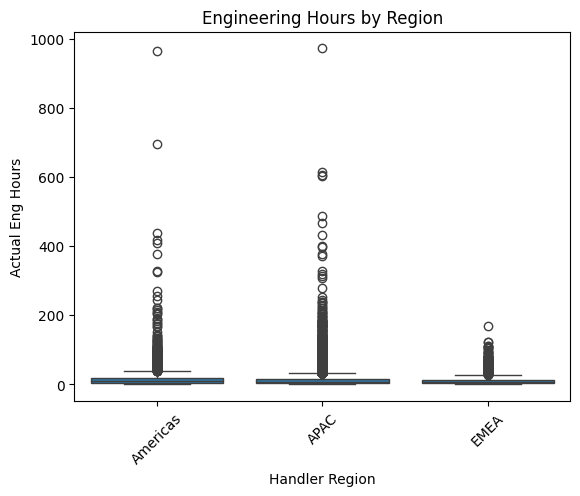

In [55]:
sns.boxplot(
    data=data,
    x="Handler Region",
    y="Actual Eng Hours"
)

plt.xticks(rotation=45)
plt.title("Engineering Hours by Region")
plt.show()


In [53]:
#correlation analysis 

numeric_cols = data.select_dtypes(include=[np.number])

corrs = numeric_cols.corr()["Actual Eng Hours"].sort_values(ascending=False)

corrs


Actual Eng Hours             1.000000
Log_Eng_Hours                0.703673
Avg Scoped Hours Engineer    0.546462
Total Scoped Hours           0.523904
Avg Scoped Hours Lab         0.359143
Actual Lab Hours             0.306499
Standard Count               0.110391
Test Count                   0.099997
Product Type Segment         0.067090
Ship to Account Number       0.008171
Flex Project Count                NaN
Name: Actual Eng Hours, dtype: float64

In [54]:
#Check Categorical Cardinality
cat_cols = data.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(col, ":", data[col].nunique())


Flex Project UUID : 46608
Confirmation Year : 3
Handler Region : 3
Product Group : 218
Product Type : 785
Product Type Code : 10
Industry Name : 33
Industry Code : 33
Service Line Code : 167
Service Line Name : 167
Service Detail : 2440
Service Program : 566
Service Catalog Category : 76
Service Catalog Item Number : 2600
Service Catalog Segment : 22
Service Catalog Sub Category : 359
CCN : 214
Ship to Customer Region : 3
Has Test Task Flag : 2
Flex Standards : 3451
